# NBA Player Longevity — Feature Engineering Pipeline
## Predicting 5-Year Career Survival from Rookie Statistics

**Author:** Abubakar Jibrin Gunda  
**Dataset:** NBA Players Stats (1,340 rookies · 20 raw features)  
**Target:** `target_5yrs` — did the player survive ≥ 5 seasons in the NBA?  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

---
### Notebook Structure
1. Load dataset & define target  
2. Drop non-predictive columns  
3. Correlation analysis & multicollinearity reduction  
4. Feature engineering — composite metrics  
5. Missing value handling  
6. Final clean dataset export & summary


## 1. Import Libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

df = pd.read_csv('nba_players.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
df.head()


Dataset shape: (1340, 21)

Columns: ['Name', 'GP', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3P Made', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'target_5yrs']

Data types:
Name               str
GP               int64
MIN            float64
PTS            float64
FGM            float64
FGA            float64
FG%            float64
3P Made        float64
3PA            float64
3P%            float64
FTM            float64
FTA            float64
FT%            float64
OREB           float64
DREB           float64
REB            float64
AST            float64
STL            float64
BLK            float64
TOV            float64
target_5yrs      int64
dtype: object


,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,target_5yrs
0,Player_0,52,36.3,11.9,2.1,3.9,0.538,1.6,4.9,0.327,...,8.2,0.732,1.6,1.0,2.7,1.9,0.9,0.4,4.5,1
1,Player_1,15,30.9,NaN,1.2,2.7,0.444,0.8,2.3,0.348,...,8.4,0.738,0.7,7.6,NaN,0.7,1.6,2.0,5.0,1
2,Player_2,72,8.0,1.2,0.2,0.5,0.400,0.1,0.2,0.500,...,4.5,0.733,1.5,2.6,4.4,8.7,1.9,1.1,2.9,0
3,Player_3,61,18.8,22.8,4.5,10.7,0.421,2.2,8.3,0.265,...,7.3,0.630,1.5,3.4,4.9,7.9,1.8,2.2,3.9,1
4,Player_4,21,34.0,14.0,3.1,6.6,0.470,0.1,0.2,0.500,...,9.8,0.643,4.0,1.2,5.4,5.7,2.7,1.2,4.3,1


## 2. Define the Target Variable

`target_5yrs` is our **binary dependent variable**:
- `1` → Player lasted **5 or more years** in the NBA  
- `0` → Player's career ended **before 5 years**

This is a **career longevity classification** problem. All numeric columns are candidate predictors.


=== target_5yrs ===
target_5yrs
Career < 5 yrs    688
Career ≥ 5 yrs    652
Name: count, dtype: int64

Class balance: 48.66% survived 5+ years
Missing in target: 0


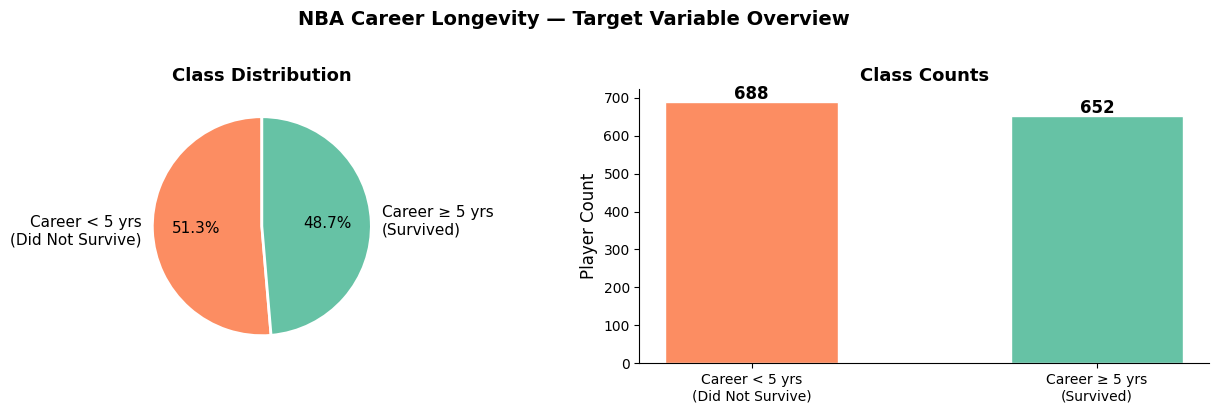

Figure saved.


In [2]:
target = df['target_5yrs']
print("=== target_5yrs ===")
print(target.value_counts().rename({0: 'Career < 5 yrs', 1: 'Career ≥ 5 yrs'}))
print(f"\nClass balance: {target.mean():.2%} survived 5+ years")
print(f"Missing in target: {target.isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = target.value_counts().sort_index()
labels = ['Career < 5 yrs\n(Did Not Survive)', 'Career ≥ 5 yrs\n(Survived)']
colors = ['#FC8D62', '#66C2A5']

axes[0].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':11})
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

axes[1].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylabel('Player Count', fontsize=12)
axes[1].set_title('Class Counts', fontsize=13, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('NBA Career Longevity — Target Variable Overview',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 3. Drop Non-Predictive Columns

| Column | Reason to Drop |
|--------|---------------|
| `Name` | Player identifier — unique string with no predictive signal. Retaining it risks **data leakage** (a model could memorise historical names) and adds no generalisable information. |

All numeric statistics are retained for correlation analysis in the next step.


In [3]:
df_raw = df.copy()
df = df.drop(columns=['Name'])
print(f"Shape after dropping Name: {df.shape}")
print(f"Remaining columns ({len(df.columns)}): {list(df.columns)}")


Shape after dropping Name: (1340, 20)
Remaining columns (20): ['GP', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3P Made', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'target_5yrs']


## 4. Correlation Analysis — Multicollinearity Reduction

### Why This Matters
Highly correlated features carry **redundant information**. In distance-based models (KNN, SVM) this biases predictions; in linear models it inflates variance. In tree ensembles it dilutes feature importance scores.

**Strategy:**  
1. Plot full correlation heatmap to spot clusters  
2. Flag all pairs with |r| > 0.85  
3. For each flagged pair, **drop the feature with weaker individual correlation to `target_5yrs`**


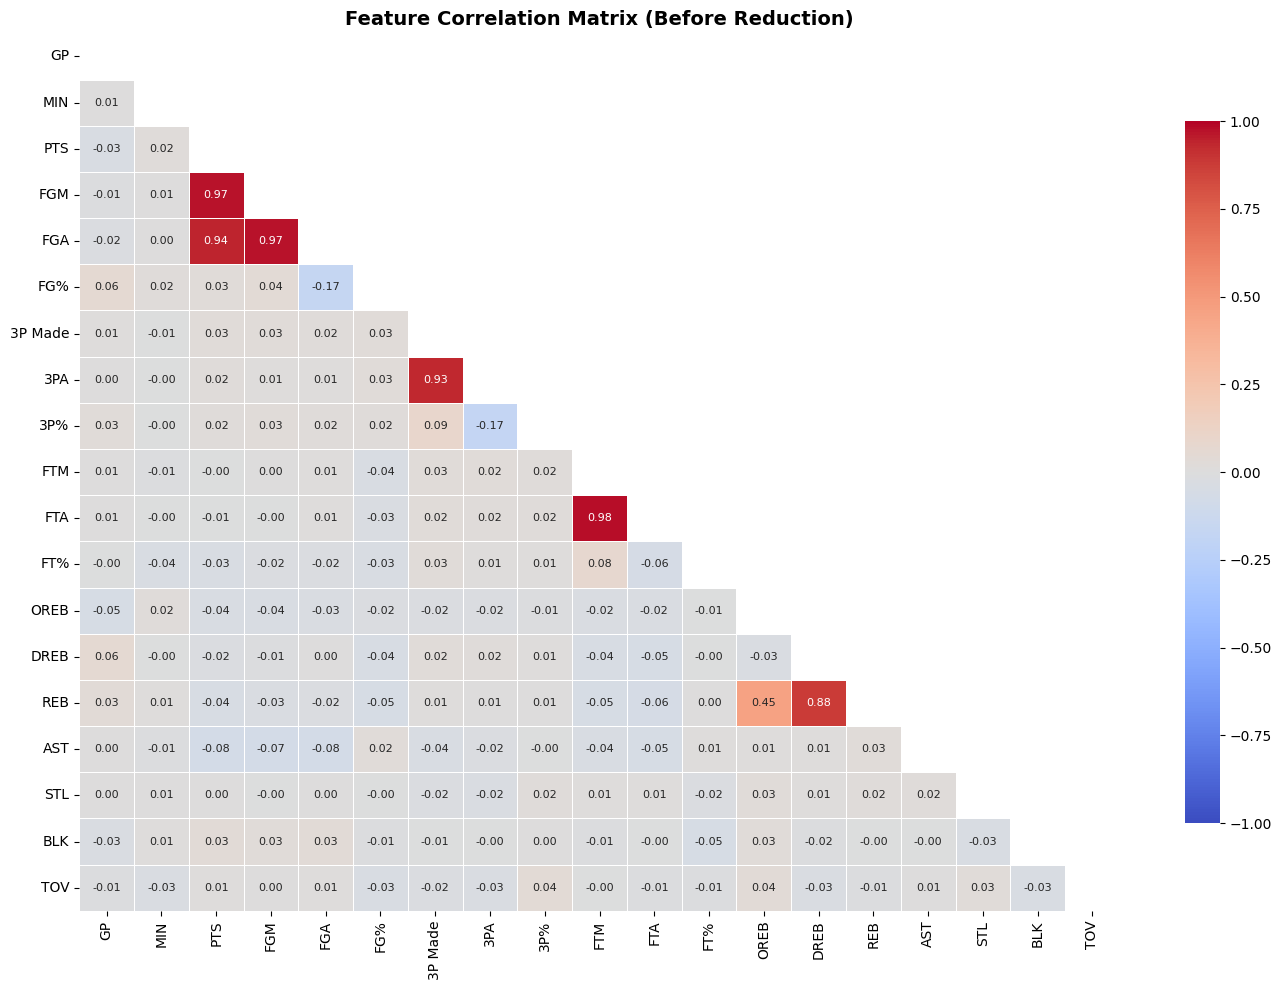

Figure saved.


In [4]:
corr = df.drop(columns=['target_5yrs']).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (Before Reduction)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [5]:
threshold = 0.85
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if abs(upper_tri.loc[row, col]) > threshold
]

print(f"Pairs with |r| > {threshold}:")
print(f"{'Feature A':<12} {'Feature B':<12} {'Correlation':>12}")
print("-" * 38)
for a, b, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{a:<12} {b:<12} {r:>12.3f}")


Pairs with |r| > 0.85:
Feature A    Feature B     Correlation
--------------------------------------
FTA          FTM                 0.978
FGM          PTS                 0.973
FGA          FGM                 0.970
FGA          PTS                 0.944
3PA          3P Made             0.933
REB          DREB                0.879


In [6]:
target_corr_abs = df.corr()['target_5yrs'].abs()

cols_to_drop = set()
for a, b, r in high_corr_pairs:
    loser = b if target_corr_abs[a] >= target_corr_abs[b] else a
    cols_to_drop.add(loser)

print("Columns removed due to multicollinearity:")
for c in sorted(cols_to_drop):
    print(f"  ✗  {c:<12}  (|corr with target| = {target_corr_abs[c]:.3f})")

df = df.drop(columns=list(cols_to_drop))
remaining_features = [c for c in df.columns if c != 'target_5yrs']
print(f"\nShape after reduction: {df.shape}")
print(f"Retained features: {remaining_features}")


Columns removed due to multicollinearity:
  ✗  3PA           (|corr with target| = 0.001)
  ✗  DREB          (|corr with target| = 0.024)
  ✗  FGA           (|corr with target| = 0.391)
  ✗  FTM           (|corr with target| = 0.018)
  ✗  PTS           (|corr with target| = 0.404)

Shape after reduction: (1340, 15)
Retained features: ['GP', 'MIN', 'FGM', 'FG%', '3P Made', '3P%', 'FTA', 'FT%', 'OREB', 'REB', 'AST', 'STL', 'BLK', 'TOV']


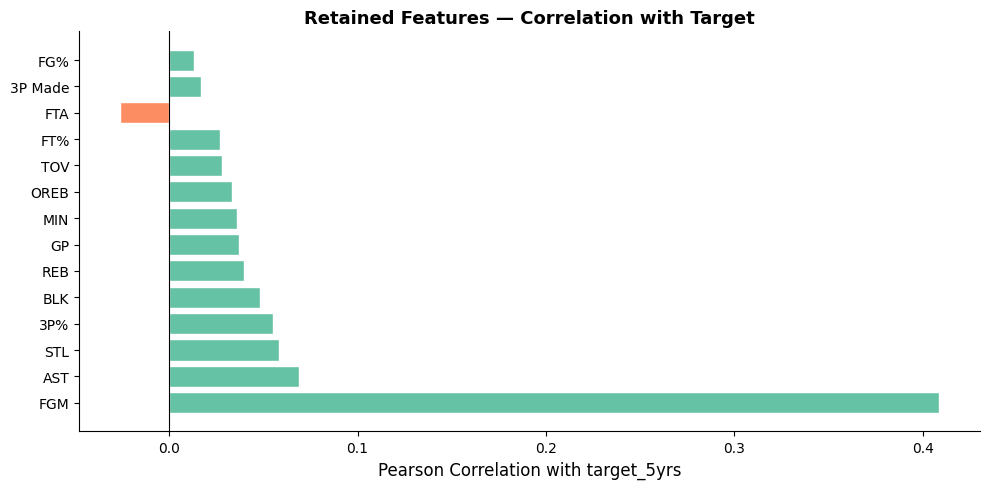

Figure saved.


In [7]:
# Correlation of retained features with target
target_corr_remaining = (df.corr()['target_5yrs']
                           .drop('target_5yrs')
                           .sort_values(key=abs, ascending=False))

plt.figure(figsize=(10, 5))
bar_colors = ['#66C2A5' if v > 0 else '#FC8D62' for v in target_corr_remaining]
plt.barh(target_corr_remaining.index, target_corr_remaining.values,
         color=bar_colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with target_5yrs', fontsize=12)
plt.title('Retained Features — Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 5. Feature Engineering — Composite Metrics

Raw counting stats reward players with heavy minutes but may be inefficient. Three derived metrics capture **quality** of play:

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `EFF_RATING` | (FGM + REB + AST + STL + BLK − (FTA − FTM) − TOV) / GP | NBA's classic efficiency formula — single-number overall contribution per game |
| `AST_TO_RATIO` | AST / (TOV + 0.001) | Ball-handling quality — high ratio signals good decision-making, a key longevity indicator |
| `REB_PER_MIN` | REB / (MIN + 0.001) | Rebounding intensity per minute — adjusts for playing time |

> **Note:** `PTS` and `FGA` were removed in the correlation step (collinear with `FGM`), so we build efficiency metrics from retained base stats.


In [8]:
# Compute EFF_RATING using available retained columns
# Formula adapted to retained features: FGM, FTA, FT%, REB, AST, STL, BLK, TOV, GP
# FTM can be recovered as FTA * FT%
df['FTM_est'] = (df['FTA'] * df['FT%']).round(1)

df['EFF_RATING'] = (
    (df['FGM'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
     - (df['FTA'] - df['FTM_est'])
     - df['TOV'])
    / df['GP']
).round(4)

# AST-to-Turnover Ratio
df['AST_TO_RATIO'] = (df['AST'] / (df['TOV'] + 0.001)).round(4)

# Rebounds per Minute
df['REB_PER_MIN'] = (df['REB'] / (df['MIN'] + 0.001)).round(4)

# Drop helper column
df = df.drop(columns=['FTM_est'])

engineered = ['EFF_RATING', 'AST_TO_RATIO', 'REB_PER_MIN']
print("Engineered features:")
print(df[engineered].describe().round(3))


Engineered features:
       EFF_RATING  AST_TO_RATIO  REB_PER_MIN
count    1261.000      1300.000     1300.000
mean        0.945         3.285        0.397
std         2.155         4.549        0.303
min         0.025         0.000        0.039
25%         0.224         1.046        0.196
50%         0.362         1.933        0.298
75%         0.715         3.498        0.484
max        24.100        48.259        2.019


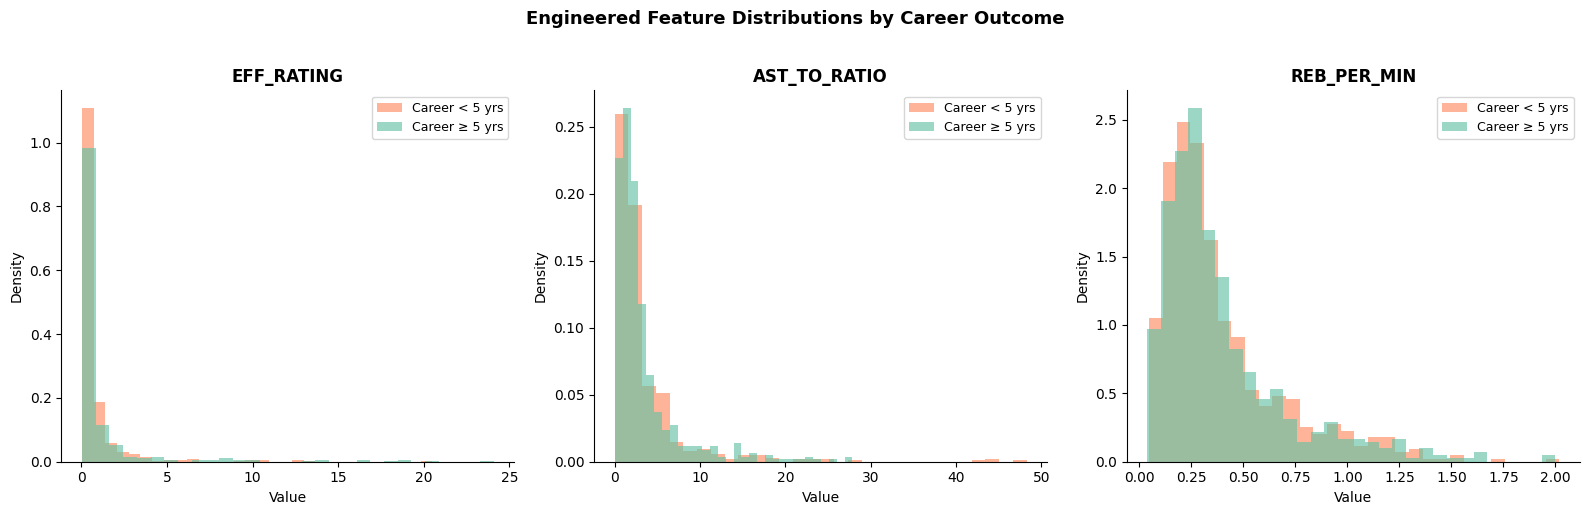

Figure saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = {0: '#FC8D62', 1: '#66C2A5'}
labels_map = {0: 'Career < 5 yrs', 1: 'Career ≥ 5 yrs'}

for ax, feat in zip(axes, engineered):
    for cls, color in palette.items():
        data = df[df['target_5yrs'] == cls][feat].dropna()
        ax.hist(data, bins=30, alpha=0.65, color=color, label=labels_map[cls], density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Engineered Feature Distributions by Career Outcome',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 6. Handle Missing Values

### Audit & Strategy

| Column Type | Method | Rationale |
|-------------|--------|-----------|
| Performance stats (PTS, REB, AST) | **Median imputation** | Median is robust to the right-skew typical in player statistics |
| Engineered features | **Re-computed after imputation** | Derived metrics recalculated on clean base stats for consistency |

**Why not drop rows?**  
Only ~3% of rows contain nulls. Dropping them wastes ~40 records and could introduce selection bias if missing data correlates with player quality. Median imputation preserves sample size without significant distortion.


In [10]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

print("=== Missing Value Audit ===")
if len(null_counts) == 0:
    print("No missing values detected.")
else:
    for col, cnt in null_counts.items():
        print(f"  {col:<15}  {cnt:>4} missing  ({cnt/len(df)*100:.1f}%)")
print(f"\nTotal null cells: {df.isnull().sum().sum()}")


=== Missing Value Audit ===
  EFF_RATING         79 missing  (5.9%)
  REB                40 missing  (3.0%)
  AST                40 missing  (3.0%)
  AST_TO_RATIO       40 missing  (3.0%)
  REB_PER_MIN        40 missing  (3.0%)

Total null cells: 239


In [11]:
# Median imputation — fit on full dataset
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target_5yrs' and c not in engineered]

medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

# Recompute engineered features on clean data
df['FTM_est'] = (df['FTA'] * df['FT%']).round(1)
df['EFF_RATING'] = (
    (df['FGM'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
     - (df['FTA'] - df['FTM_est']) - df['TOV'])
    / df['GP']
).round(4)
df['AST_TO_RATIO'] = (df['AST'] / (df['TOV'] + 0.001)).round(4)
df['REB_PER_MIN']  = (df['REB'] / (df['MIN'] + 0.001)).round(4)
df = df.drop(columns=['FTM_est'])

print(f"Missing values after imputation: {df.isnull().sum().sum()}")
print("✅ All nulls resolved via median imputation.")
print(f"\nFinal dataset shape: {df.shape}")


Missing values after imputation: 0
✅ All nulls resolved via median imputation.

Final dataset shape: (1340, 18)


## 7. Final Clean Dataset — Export & Summary

In [12]:
all_features = [c for c in df.columns if c != 'target_5yrs']
original_retained = [c for c in all_features if c not in engineered]

print("=" * 50)
print("  FINAL FEATURE ENGINEERING SUMMARY")
print("=" * 50)
print(f"  Total samples          : {df.shape[0]}")
print(f"  Original features kept : {len(original_retained)}")
print(f"  Engineered features    : {len(engineered)}")
print(f"  Total features         : {len(all_features)}")
print(f"  Missing values         : {df.isnull().sum().sum()}")
print("=" * 50)

df.to_csv('nba_features_clean.csv', index=False)
print("\n✅ Saved → nba_features_clean.csv")
df.describe().round(3)


  FINAL FEATURE ENGINEERING SUMMARY
  Total samples          : 1340
  Original features kept : 14
  Engineered features    : 3
  Total features         : 17
  Missing values         : 0

✅ Saved → nba_features_clean.csv


,GP,MIN,FGM,FG%,3P Made,3P%,FTA,FT%,OREB,REB,AST,STL,BLK,TOV,target_5yrs,EFF_RATING,AST_TO_RATIO,REB_PER_MIN
count,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000,1340.000
mean,39.362,21.550,3.100,0.442,1.470,0.345,4.733,0.744,1.998,6.454,5.148,1.516,1.540,2.645,0.487,0.952,3.321,0.396
std,23.003,9.551,1.804,0.057,0.859,0.082,2.756,0.113,1.180,2.450,2.843,0.853,0.867,1.394,0.500,2.155,4.561,0.302
min,1.000,5.100,0.100,0.333,0.000,0.000,0.000,0.000,0.000,1.100,0.000,0.000,0.000,0.200,0.000,0.025,0.000,0.039
25%,19.000,13.175,1.600,0.393,0.700,0.288,2.400,0.674,0.975,4.500,2.800,0.800,0.800,1.475,0.000,0.224,1.083,0.198
50%,39.000,21.900,3.000,0.436,1.500,0.333,4.700,0.740,2.000,6.400,5.300,1.500,1.500,2.700,0.000,0.362,1.937,0.296
75%,59.000,29.625,4.500,0.491,2.200,0.400,7.000,0.812,3.000,8.300,7.500,2.200,2.300,3.900,1.000,0.719,3.542,0.482
max,81.000,38.000,7.400,0.600,3.000,0.500,10.700,1.000,4.000,12.100,10.000,3.000,3.000,5.000,1.000,24.100,48.259,2.019


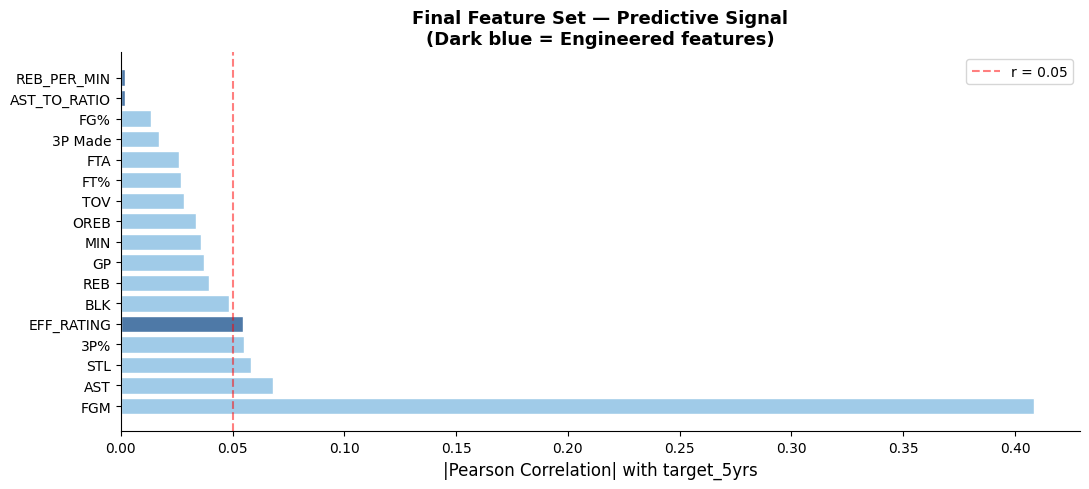

Figure saved.


In [13]:
# Final correlation with target — full feature set
feat_corr = df.corr()['target_5yrs'].drop('target_5yrs').abs().sort_values(ascending=False)

bar_cols = ['#4E79A7' if c in engineered else '#A0CBE8' for c in feat_corr.index]
plt.figure(figsize=(11, 5))
plt.barh(feat_corr.index, feat_corr.values, color=bar_cols, edgecolor='white')
plt.xlabel('|Pearson Correlation| with target_5yrs', fontsize=12)
plt.title('Final Feature Set — Predictive Signal\n(Dark blue = Engineered features)',
          fontsize=13, fontweight='bold')
plt.axvline(0.05, color='red', linestyle='--', alpha=0.5, label='r = 0.05')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('final_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 8. Pipeline Decisions — Rationale Summary

### Feature Drops
| Dropped | Reason |
|---------|--------|
| `Name` | String identifier, no predictive value, leakage risk |
| `PTS`, `FGA`, `FTM`, `DREB`, `3PA` | |r| > 0.85 with a retained peer; weaker individual link to target |

### Engineering Choices
| Feature | Signal Captured |
|---------|----------------|
| `EFF_RATING` | All-round contribution per game — the NBA's own efficiency benchmark |
| `AST_TO_RATIO` | Decision-making quality — players who assist more than they turn it over last longer |
| `REB_PER_MIN` | Rebounding work rate adjusted for playing time |

### Null Handling
Median imputation was chosen over mean (robust to star-player outliers) and over row deletion (preserves ~40 records, ~3% of data). In a production ML pipeline, the median would be computed on training data only to prevent leakage into held-out evaluation sets.

---
*This dataset is now ready for classification modelling (Logistic Regression, Random Forest, XGBoost, etc.).*
